## Question 8 - Assingment 1

Create two lists:

    `students` = `["Asha", "Ben", "Carlos", "Diya", "Evan"]`\
    `marks` = `[72, 85, 64, 90, 58]`

    Create one more empty list `grade`:\
    Using a loop, assign the grades based on the following condition
    
    - "A" if mark ≥ 85
    - "B" if 70 ≤ mark < 85
    - "C" if 50 ≤ mark < 70
    - "F" if mark < 50
    
Using a loop, print each student’s name, mark, and grade.\
Count and print how many students passed (mark ≥ 50).

In [6]:
students = ['Asha', 'Ben', 'Carlos', 'Divya', 'Evan']
marks = [72, 85, 64, 90, 58]
grade = []

for mark in marks:
    if mark >= 90:
        grade.append('A')
    elif mark >= 80:
        grade.append('B')
    elif mark >= 70:
        grade.append('C')
    elif mark >= 60:
        grade.append('D')
    else:
        grade.append('F')


def students_passed(marks):
    count = 0
    for i in marks:
        if(i >= 50):
            count += 1
    return count

for i in range(len(marks)):
    print('{s}, {m}, {g}'.format(s=students[i], m=marks[i], g=grade[i]))


Asha, 72, C
Ben, 85, B
Carlos, 64, D
Divya, 90, A
Evan, 58, F


## Question 8 - Assignment 2

Create a 'function rotate_list($x, y, \theta$)' to rotate a given set of coordinates in the two lists $x$, $y$ as in the previous problem and returns the rotated lists $x, y$ after rotation by the angle $\theta$ in radians. The input argument of function 'function rotate_list($x, y, \theta$)' are the lists $x$, $y$, which can be obtained from the function 'smiley()' or 'ngon()'. Then plot both the original and rotated smiley face or polygon on the same figure.

[ 0.          0.95105652  0.58778525 -0.58778525 -0.95105652  0.        ]
[ 0.          0.95105652  0.58778525 -0.58778525 -0.95105652  0.        ]


(np.float64(-1.1),
 np.float64(1.1),
 np.float64(-1.046162167924669),
 np.float64(1.046162167924669))

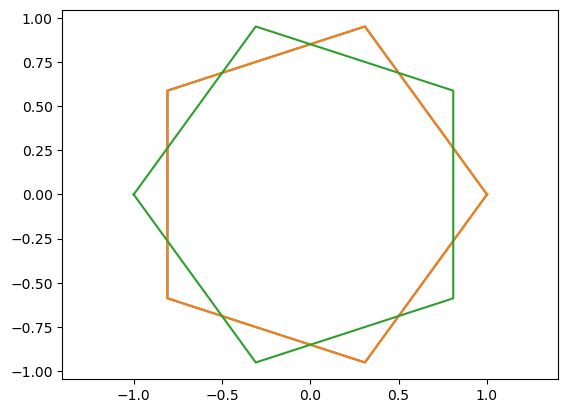

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def ngon(n):
    if n <= 2:
        raise ValueError("n must be greater than 2")

    # Generate n equally spaced angles
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    # Convert angles to coordinates (unit circle)
    x = np.cos(theta)
    y = np.sin(theta)

    # Close the polygon by repeating the first point
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    print(y)
    return x, y

x, y = ngon(5)
plt.plot(x, y);
plt.axis("equal")

def rotate_list(x, y, theta):
    x_rot = x * np.cos(theta) - y * np.sin(theta)
    y_rot = x * np.sin(theta) + y * np.cos(theta)
    return x_rot, y_rot

x, y = ngon(5)
plt.plot(x, y, label='original shape')

xr, yr = rotate_list(x, y, 2*np.pi/2)
plt.plot(xr, yr, label='rotated shape')

plt.axis('equal')

## Question 10: Assinment 2 (Cobweb plot)


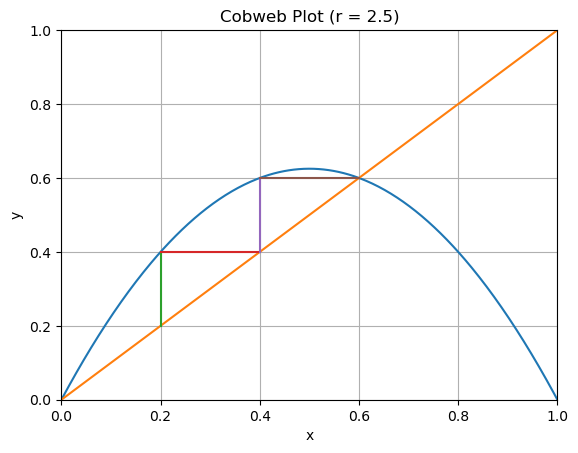

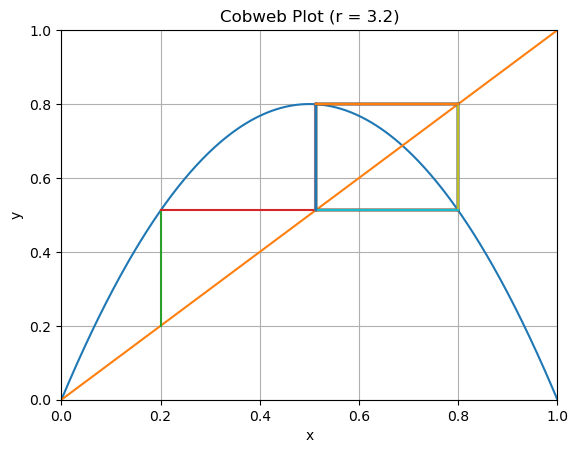

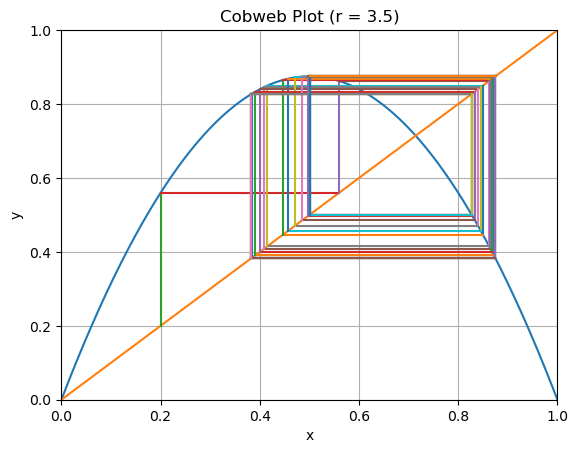

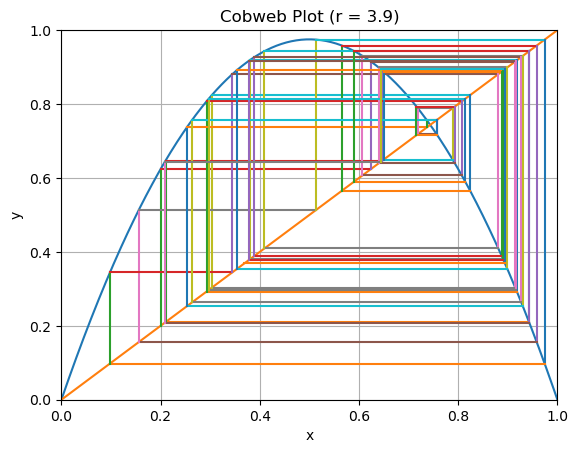

In [13]:
def logistic_function(x, r):
    return r * x * (1 - x)

def cobweb_plot(r, x0, n_iter):
    # Create x values for smooth curve
    x = np.linspace(0, 1, 400)
    y = logistic_function(x, r)

    # Plot logistic curve
    plt.plot(x, y)

    # Plot diagonal y = x
    plt.plot(x, x)

    # Initial point
    x_n = x0

    for _ in range(n_iter):
        # Vertical line: (x_n, x_n) → (x_n, f(x_n))
        y_n = logistic_function(x_n, r)
        plt.plot([x_n, x_n], [x_n, y_n])

        # Horizontal line: (x_n, y_n) → (y_n, y_n)
        plt.plot([x_n, y_n], [y_n, y_n])

        # Update
        x_n = y_n

    plt.title(f"Cobweb Plot (r = {r})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)


r_values = [2.5, 3.2, 3.5, 3.9]

for r in r_values:
    plt.figure()
    cobweb_plot(r, x0=0.2, n_iter=50)

plt.show()


### Task:
 1.  Calculate the Pearson correlation coefficient ($r$) between Hours and Scores.
 2.  Generate a scatter plot where the size of each point increases based on how far that student's score is from the mean (use the squared difference as the size).
 3. Output: Display the plot with the correlation coefficient $r$ included in the title.

Text(0.5, 1.0, 'Correlation Coefficient r=0.98')

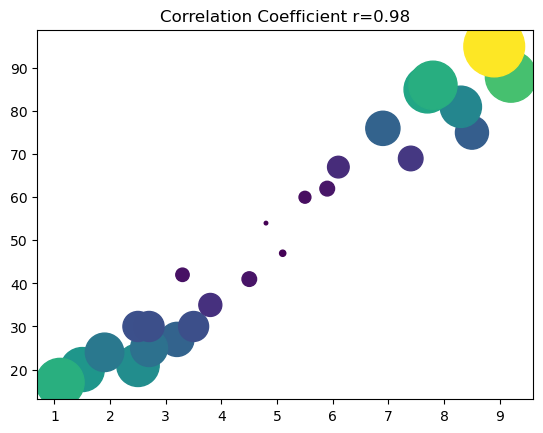

In [16]:
import numpy as np
import matplotlib.pyplot as plt

hours, scores = np.loadtxt('data/studentscores.csv', delimiter=',', skiprows=1, unpack=True)

r = np.corrcoef(hours, scores)[0, 1]
s = (hours - np.mean(hours))**2 + (scores - np.mean(scores))**2
plt.scatter(hours, scores, c=s, s=s)
plt.title('Correlation Coefficient r={}'.format(round(r, 2)))

## Q1 - Assignment 4

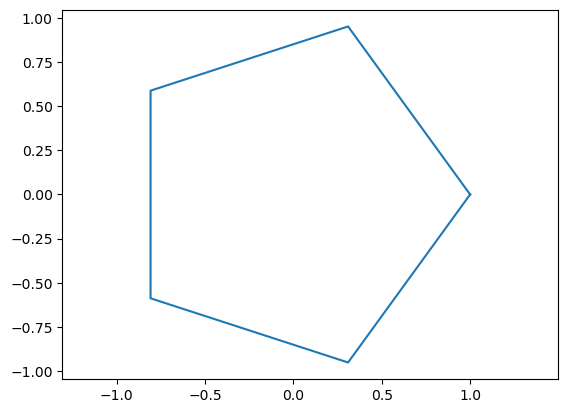

interactive(children=(IntSlider(value=3, description='n', max=20, min=3), Output()), _dom_classes=('widget-int…

In [20]:
import ipywidgets as widgets

def ngon(n):
    if n <= 2:
        raise ValueError("n must be greater than 2")
    
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    x = np.cos(theta)
    y = np.sin(theta)

    x = np.append(x, x[0])
    y = np.append(y, y[0])
    plt.plot(x, y)
    plt.axis('equal')
    return x, y

x, y = ngon(5)
widgets.interact(lambda n: ngon(n), n=widgets.IntSlider(min=3, max=20));

## Question 8 - Assignment 4

In [21]:
import numpy as np
import matplotlib.pyplot as plt

kohli_data = np.loadtxt('data/kohli.txt')
num_simulations = 100000
max_scores = []

for _ in range(num_simulations):
    series = np.random.choice(kohli_data, size=3, replace=True)
    max_score = np.max(series)
    max_scores.append(max_score)

max_scores = np.array(max_scores)

lower = np.percentile(max_scores, 25)
upper = np.percentile(max_scores, 75)

print(f"50% confidence interval for the maximum score in a 3-match series:")
print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")

50% confidence interval for the maximum score in a 3-match series:
Lower bound: 59.00
Upper bound: 115.00
